<a href="https://colab.research.google.com/github/haf5th/PCVK_Ganjil2026/blob/main/Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Import Library Utama
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from google.colab.patches import cv2_imshow
import math

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


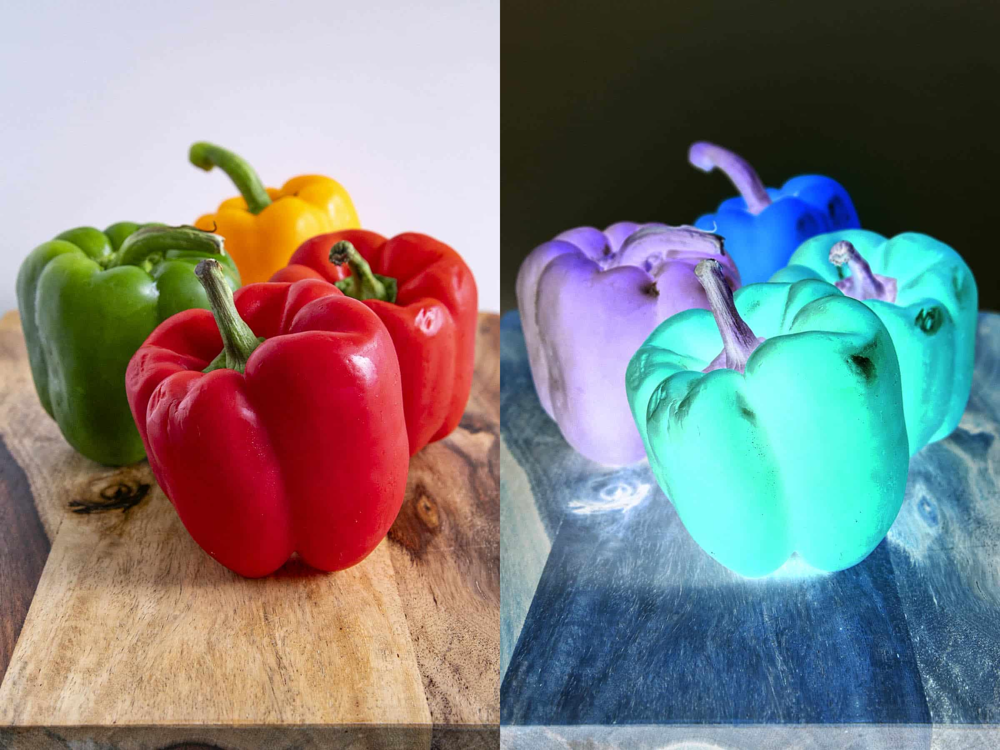

In [ ]:
img = cv.imread('/content/drive/MyDrive/PCVK/Bell-Peppers1.jpg')
inverse_img = 255 - img

cv2_imshow(cv.hconcat((img, inverse_img)))

Mengubah kontras dan tingkat kecerahan citra
Masukkan tingkat kecerahan: 30
Masukkan kontras: 1


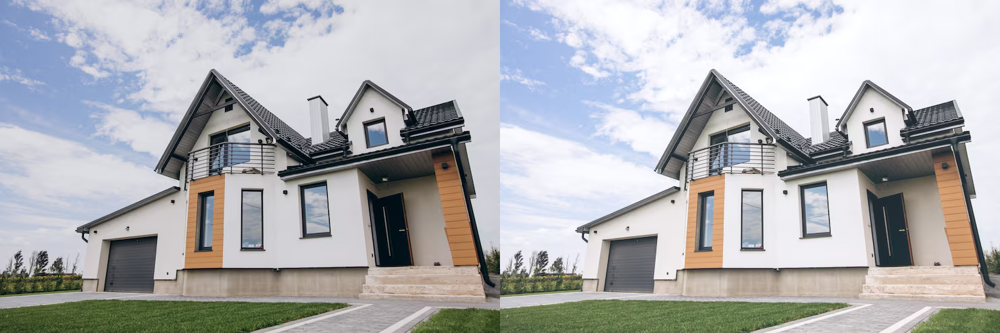

In [ ]:
print('Mengubah kontras dan tingkat kecerahan citra')
try:
    brightness = int(input('Masukkan tingkat kecerahan: '))
    contrast = float(input('Masukkan kontras: '))
except ValueError:
    print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/PCVK/house-isolated-field_1303-23773.avif')
contrast_img = np.zeros(img.shape, img.dtype)

# Menghitung contrast & brightness
for y in range(img.shape[0]):
    for x in range(img.shape[1]):
        for c in range(img.shape[2]):
            contrast_img[y, x, c] = np.clip(contrast * img[y, x, c] + brightness, 0, 255)

final = cv.hconcat((img, contrast_img))
cv2_imshow(final)

Mengubah tingkat kecerahan citra dengan Transformasi Log
Masukkan nilai kecerahan / konstanta: 50


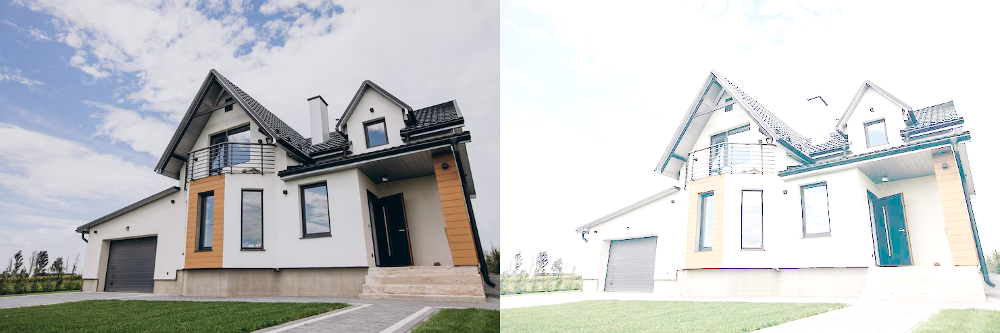

In [ ]:
#Transformasi Logarithmic Brightness
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
try:
    c_val = float(input('Masukkan nilai kecerahan / konstanta: '))
except ValueError:
    print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/PCVK/house-isolated-field_1303-23773.avif')

# Konversi citra ke float untuk perhitungan logaritma
img_float = img.astype(np.float32)

# Rumus Logarithmic Transformation: s = c * log(1 + r)
# Menggunakan log1p (log(1 + x))
c = 255 / np.log(1 + np.max(img_float)) if c_val == 0 else c_val
log_img = c * np.log1p(img_float)
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

final = cv.hconcat((img, log_img))
cv2_imshow(final)

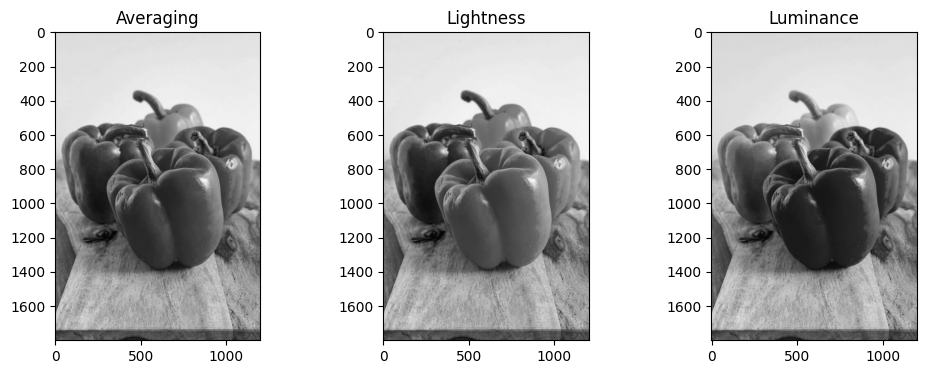

In [ ]:
#Transformasi Grayscale (Averaging, Lightness, Luminance)
img_bgr = cv.imread('/content/drive/MyDrive/PCVK/Bell-Peppers1.jpg')
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

R = img_rgb[:, :, 0].astype(np.float32)
G = img_rgb[:, :, 1].astype(np.float32)
B = img_rgb[:, :, 2].astype(np.float32)

# a. Averaging
gray_avg = ((R + G + B) / 3).astype(np.uint8)

# b. Lightness
gray_lightness = ((np.maximum(np.maximum(R, G), B) + np.minimum(np.minimum(R, G), B)) / 2).astype(np.uint8)

# c. Luminance
gray_luminance = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

# Visualisasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(gray_avg, cmap='gray'); plt.title('Averaging')
plt.subplot(1, 3, 2); plt.imshow(gray_lightness, cmap='gray'); plt.title('Lightness')
plt.subplot(1, 3, 3); plt.imshow(gray_luminance, cmap='gray'); plt.title('Luminance')
plt.show()

Masukkan nilai Gamma: 0.5


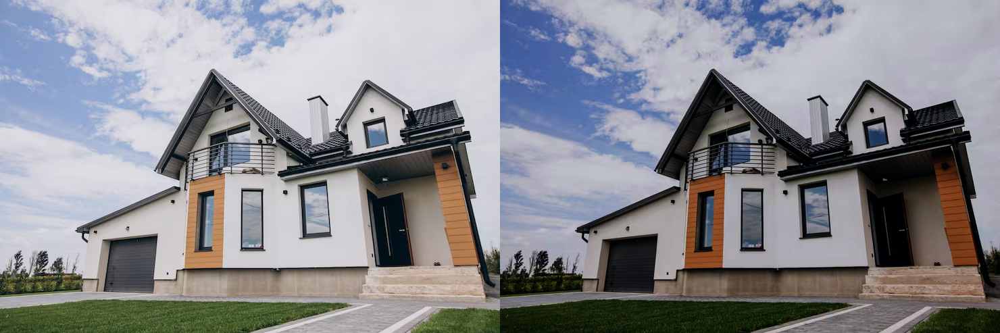

In [ ]:
#Gamma Correction
gamma = float(input('Masukkan nilai Gamma: '))
img = cv.imread('/content/drive/MyDrive/PCVK/house-isolated-field_1303-23773.avif')

gamma_corrected = np.array(255 * (img / 255.0) ** (1.0 / gamma), dtype='uint8')

cv2_imshow(cv.hconcat((img, gamma_corrected)))

Masukkan bit depth tujuan (1-8): 3


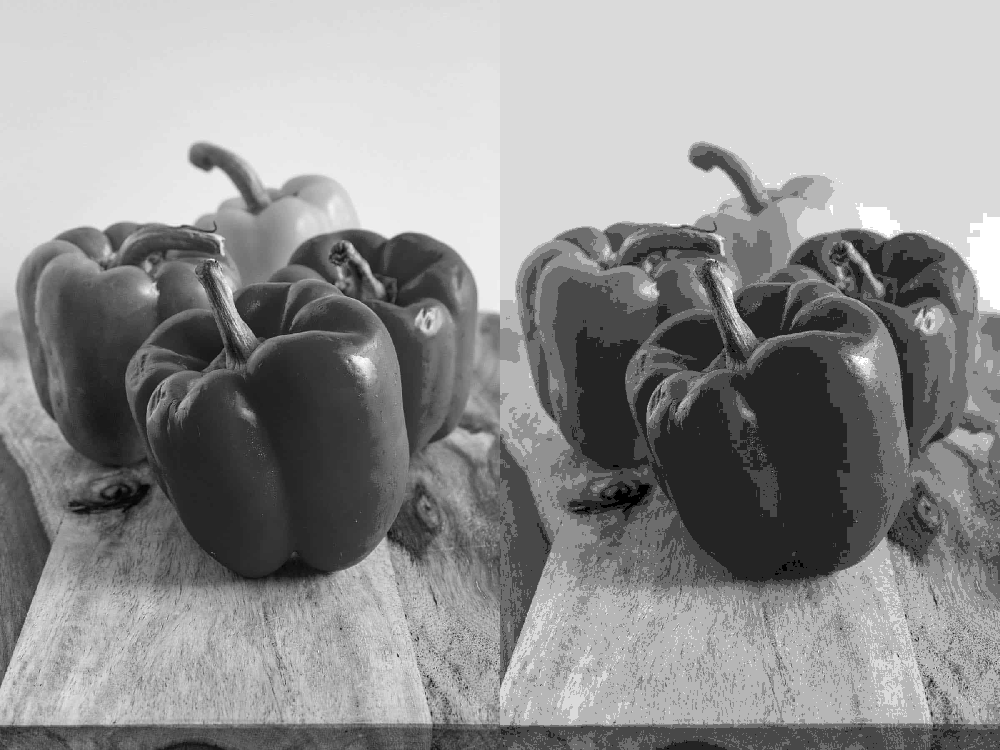

In [ ]:
bit_depth = int(input("Masukkan bit depth tujuan (1-8): "))
level = 255.0 / (pow(2, bit_depth) - 1)

original = cv.imread('/content/drive/MyDrive/PCVK/Bell-Peppers1.jpg', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original / level) * level
depth_image = np.clip(depth_image, 0, 255).astype(np.uint8)

cv2_imshow(cv.hconcat((original, depth_image)))

N=10, PSNR=29.37 dB
N=20, PSNR=30.80 dB
N=40, PSNR=31.74 dB
N=80, PSNR=32.30 dB
N=100, PSNR=32.42 dB


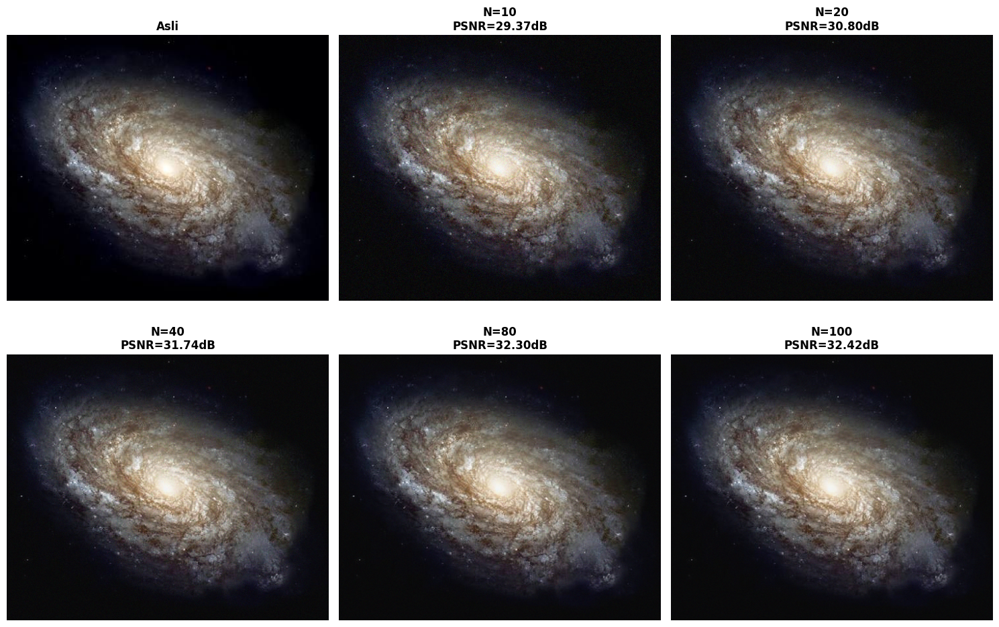

In [ ]:
import cv2
# Load gambar
img = cv2.imread('/content/drive/MyDrive/PCVK/images (2).jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Fungsi PSNR
def calculate_psnr(original, noisy):
    mse = np.mean((original.astype(float) - noisy.astype(float)) ** 2)
    return 20 * np.log10(255.0 / np.sqrt(mse)) if mse != 0 else float('inf')

# Parameter
sigma = 25
num_images_list = [10, 20, 40, 80, 100]
results = []
filtered_images = {}

# Proses filtering
for num_images in num_images_list:
    filtered = np.zeros_like(img, dtype=float)
    for _ in range(num_images):
        noise = np.random.normal(0, sigma, img.shape)
        noisy = np.clip(img.astype(float) + noise, 0, 255)
        filtered += noisy / num_images

    filtered = np.clip(filtered, 0, 255).astype(np.uint8)
    filtered_images[num_images] = filtered
    psnr = calculate_psnr(img, filtered)
    results.append({'num': num_images, 'psnr': psnr})
    print(f"N={num_images}, PSNR={psnr:.2f} dB")

# Tampilkan gambar
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

axes[0].imshow(img_rgb)
axes[0].set_title('Asli', fontweight='bold')
axes[0].axis('off')

for i, num_images in enumerate(num_images_list, 1):
    axes[i].imshow(cv2.cvtColor(filtered_images[num_images], cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'N={num_images}\nPSNR={results[i-1]["psnr"]:.2f}dB', fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


Apakah peningkatan jumlah citra memberikan peningkatan PSNR yang signifikan?

YA. Semakin banyak citra yang dirata-rata, semakin tinggi nilai PSNR. Ini terjadi karena:

Averaging mengurangi noise secara statistik
Noise random saling membatalkan ketika di-average
Struktur gambar asli terpreservasi lebih baik
Pada jumlah citra berapa peningkatan mulai tidak signifikan?

Peningkatan paling signifikan terjadi dari 10→20→40. Setelah 80 citra, peningkatan mulai menurun (diminishing returns).

Apa kesimpulan yang Anda peroleh dari percobaan ini?

Kesimpulan: Averaging adalah teknik filtering efektif untuk mengurangi Gaussian Noise, namun efektivitasnya berkurang seiring bertambahnya jumlah citra. Trade-off antara kualitas (PSNR) dan waktu komputasi perlu dipertimbangkan.

--- Masking yang digunakan (Untuk Kolom Image Input) ---


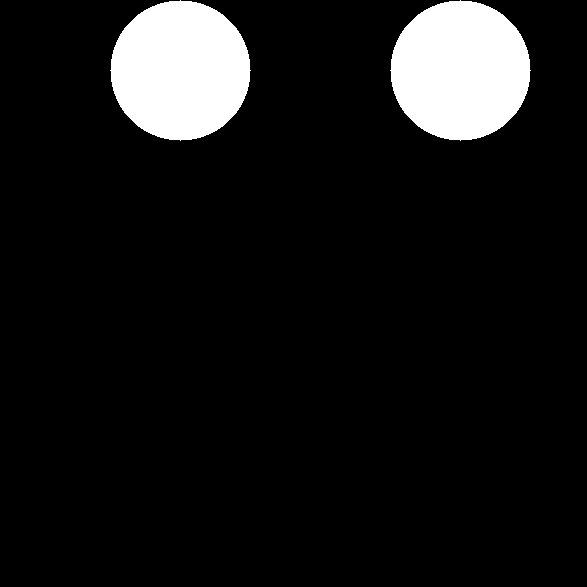


------------------------------------------------------

1. NOT (Komplemen Citra Asli)


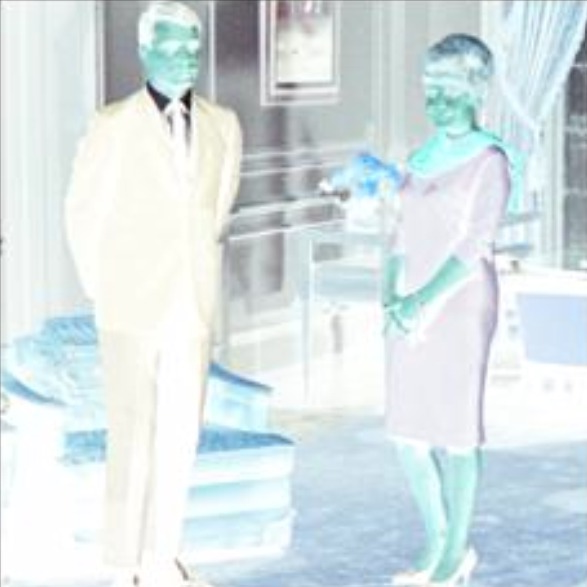


2. OR


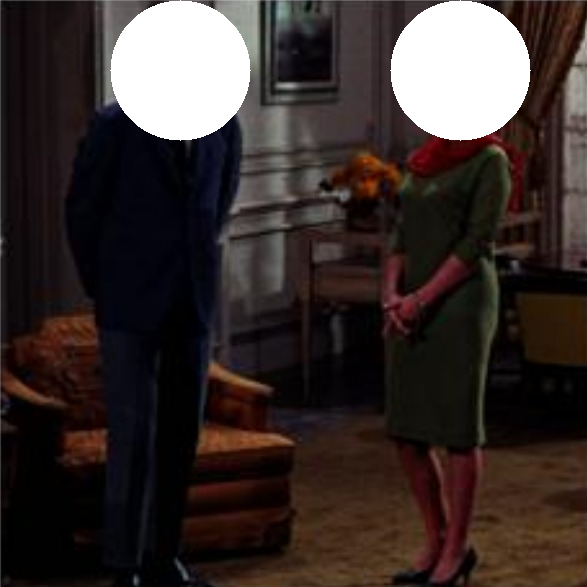


3. AND (Image Masking)


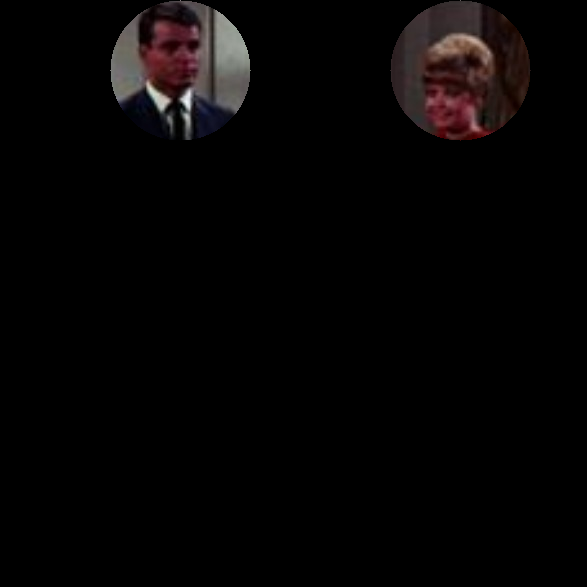


4. NAND


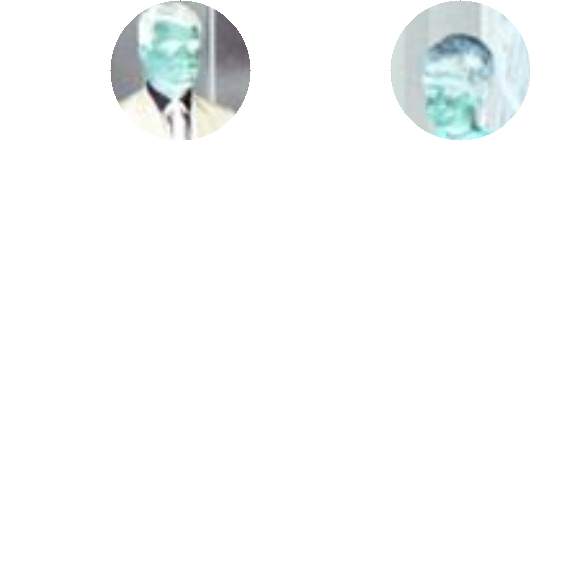


5. XOR


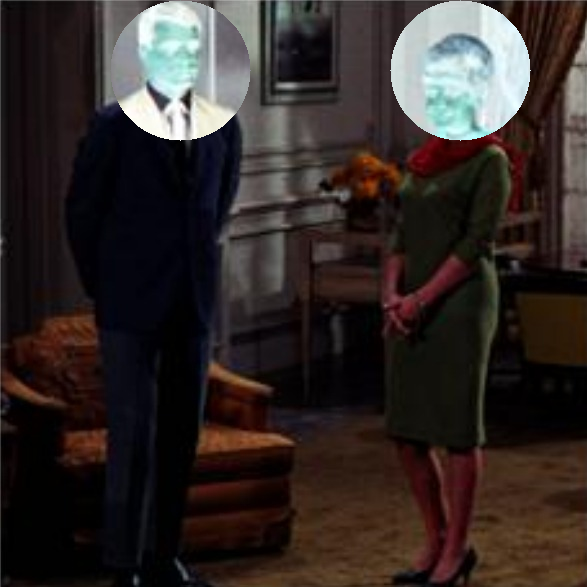

In [ ]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

img_couple = cv.imread('//content/drive/MyDrive/PCVK/64c64e48-5009-483b-b5db-0aafb3f8c0a0.jpg')

# Membuat kanvas hitam dengan ukuran yang sama dengan gambar asli
mask = np.zeros_like(img_couple)

# Adjust posisi lingkaran untuk tepat di wajah pria (kiri) dan wanita (kanan)
cv.circle(mask, (180, 70), 70, (255, 255, 255), -1)   # Wajah pria (kiri)
cv.circle(mask, (460, 70), 70, (255, 255, 255), -1)  # Wajah wanita (kanan)

print("--- Masking yang digunakan (Untuk Kolom Image Input) ---")
cv2_imshow(mask)
print("\n------------------------------------------------------\n")

print("1. NOT (Komplemen Citra Asli)")
cv2_imshow(cv.bitwise_not(img_couple))

print("\n2. OR")
cv2_imshow(cv.bitwise_or(img_couple, mask))

print("\n3. AND (Image Masking)")
cv2_imshow(cv.bitwise_and(img_couple, mask))

print("\n4. NAND")
cv2_imshow(cv.bitwise_not(cv.bitwise_and(img_couple, mask)))

print("\n5. XOR")
cv2_imshow(cv.bitwise_xor(img_couple, mask))


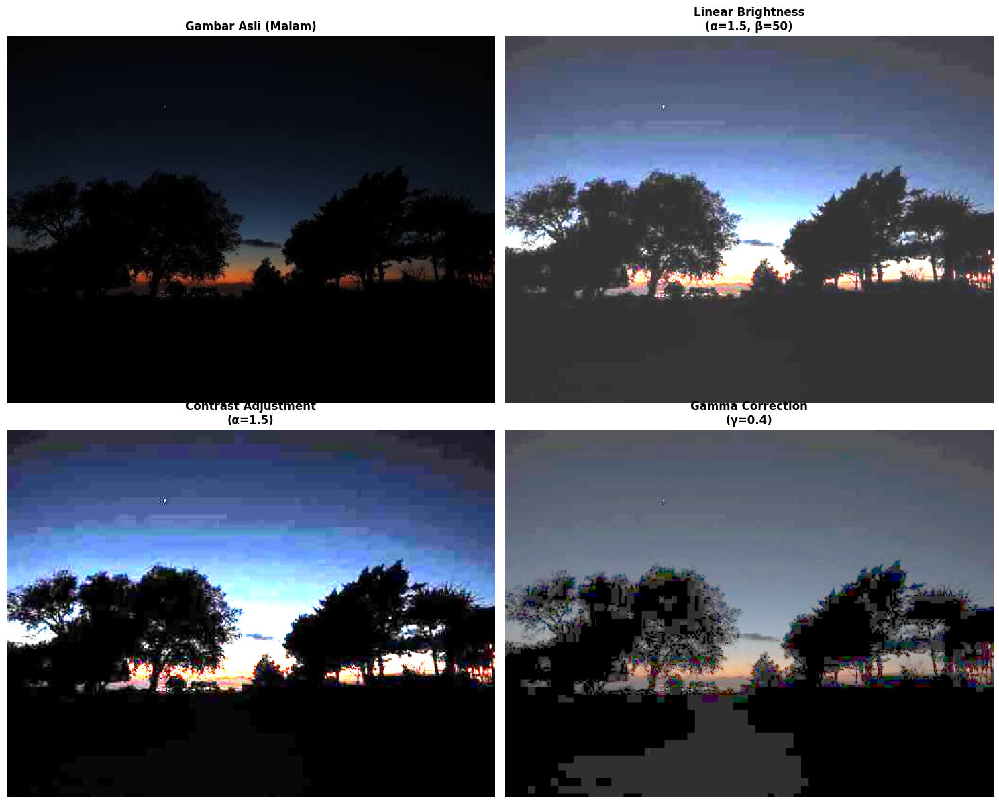

In [ ]:
#foto malam hari
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow

# Load gambar
img = cv.imread('/content/drive/MyDrive/PCVK/images (3).jpg')

# Konversi ke RGB untuk matplotlib
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# 1. LINEAR BRIGHTNESS
def linear_brightness(img, alpha=1.5, beta=50):
    result = cv.convertScaleAbs(img, alpha=alpha, beta=beta)
    return result

# 2. CONTRAST
def contrast_adjustment(img, alpha=1.5):
    result = cv.convertScaleAbs(img, alpha=alpha, beta=0)
    return result

# 3. GAMMA CORRECTION
def gamma_correction(img, gamma=0.5):
    # Normalisasi 0-1
    img_normalized = img.astype(float) / 255.0
    # Aplikasikan gamma
    result = np.power(img_normalized, gamma)
    # Kembali ke 0-255
    result = (result * 255).astype(np.uint8)
    return result

# Terapkan ketiga metode
brightness_result = linear_brightness(img, alpha=4.5, beta=50)
contrast_result = contrast_adjustment(img, alpha=7.5)
gamma_result = gamma_correction(img, gamma=0.3)

# Tampilkan hasil
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Gambar Asli (Malam)', fontweight='bold', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(cv.cvtColor(brightness_result, cv.COLOR_BGR2RGB))
axes[0, 1].set_title('Linear Brightness\n(α=1.5, β=50)', fontweight='bold', fontsize=12)
axes[0, 1].axis('off')

axes[1, 0].imshow(cv.cvtColor(contrast_result, cv.COLOR_BGR2RGB))
axes[1, 0].set_title('Contrast Adjustment\n(α=1.5)', fontweight='bold', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(cv.cvtColor(gamma_result, cv.COLOR_BGR2RGB))
axes[1, 1].set_title('Gamma Correction\n(γ=0.4)', fontweight='bold', fontsize=12)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()



1. Linear Brightness
Alasan Penggunaan
Metode ini sangat sederhana dan cepat karena hanya menambah nilai pixel secara langsung. Cocok digunakan untuk foto yang sedikit gelap karena efektif meningkatkan kecerahan keseluruhan. Parameter alpha dan beta mudah disesuaikan, dan tidak memerlukan operasi matematis kompleks sehingga komputasi sangat ringan.

Risiko
Risiko utama adalah clipping atau saturasi, dimana pixel yang sudah terang akan menjadi putih sempurna (255) dan kehilangan detail. Loss of detail terjadi di area yang sudah cerah karena warna dan tekstur hilang. Metode ini juga memperkuat noise di area gelap bersamaan dengan peningkatan brightness. Hasil yang dihasilkan terlihat over-exposed dan kurang natural. Karena tidak adaptif, metode ini meningkatkan brightness semua area secara sama, padahal foto malam membutuhkan perlakuan berbeda untuk area gelap dan terang.

2. Contrast Adjustment
Alasan Penggunaan
Contrast adjustment meningkatkan perbedaan detail sehingga objek lebih terlihat jelas. Metode ini memperjelas struktur gambar dengan membuat area gelap lebih gelap dan area terang lebih terang. Cocok untuk foto low-contrast yang terlihat flat dan bland. Dengan memperkuat edge detection, detail tepi menjadi lebih tajam sehingga gambar terlihat lebih defined.

Risiko
Risiko terbesar adalah amplifikasi noise berlebihan karena noise di area gelap akan diperkuat secara signifikan. Clipping terjadi di kedua sisi dimana pixel gelap bisa menjadi 0 (hitam) dan pixel terang menjadi 255 (putih), menyebabkan hilangnya informasi di shadow dan highlight. Warna tidak terlihat natural karena saturasi bisa terlalu berlebihan. Metode ini tidak cocok untuk foto sangat gelap karena hasil tetap gelap tanpa menambah absolute brightness. Halo effect juga bisa muncul sebagai artifact di batas tepi yang kontras.

3. Gamma Correction
Alasan Penggunaan
Gamma correction menggunakan perbaikan non-linear yang menyesuaikan brightness secara proporsional. Pixel gelap ditingkatkan lebih dari pixel terang, sehingga detail di shadow dan highlight tetap terjaga lebih baik. Hasil yang dihasilkan lebih natural karena mirip dengan persepsi mata manusia. Noise amplification berkurang karena noise di area gelap tidak diperkuat sebanding dengan brightness. Ini adalah standar industri yang digunakan di film, fotografi, dan display device. Parameter gamma juga fleksibel dan mudah disesuaikan untuk kontrol yang lebih presisi.

Risiko
Meskipun lebih baik, gamma correction masih mengalami clipping pada nilai ekstrem, terutama jika gamma terlalu kecil (kurang dari 0.3) dimana area gelap bisa menjadi over-bright. Noise tetap mengalami amplifikasi, hanya lebih terkontrol dibanding brightness dan contrast. Metode ini memerlukan tuning karena gamma value perlu dicari secara empiris melalui trial dan error. Hasilnya tidak universal karena setiap foto membutuhkan gamma value yang berbeda. Untuk foto dengan extreme darkness, gamma correction saja tetap sulit karena keterbatasan dalam memperbaiki gelap yang sangat ekstrem.

Perbandingan Umum
Linear brightness adalah metode paling sederhana namun paling berisiko untuk foto malam karena amplifikasi noise dan clipping yang parah. Contrast adjustment memberikan hasil yang sedikit lebih baik untuk meningkatkan detail, namun tetap menghadapi masalah clipping dan noise amplification.

Gamma correction adalah pilihan terbaik untuk foto malam karena memberikan hasil paling natural sambil mempertahankan detail di area shadow dan highlight. Metode ini mengurangi amplifikasi noise dengan cara yang lebih intelligent dibanding dua metode sebelumnya. Untuk hasil optimal, gamma correction sebaiknya dikombinasikan dengan denoising filter seperti bilateral filter atau NLM untuk mengatasi amplifikasi noise yang masih terjadi.

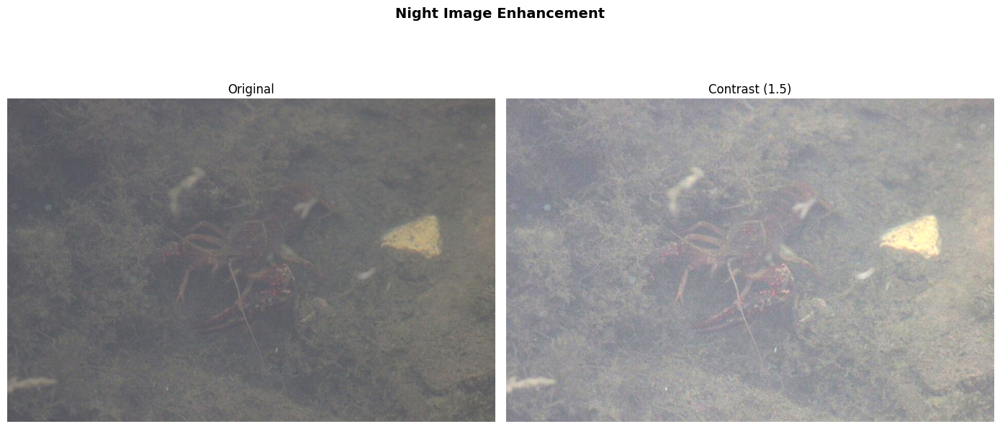

In [ ]:
IMAGE_PATH = "/content/drive/MyDrive/PCVK/CRAYFISH.jpeg"
ALPHA_CONTRAST = 1.5
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
contrast_image = cv2.cvtColor(contrast_adjustment(original, ALPHA_CONTRAST, 0), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Night Image Enhancement', fontsize=14, fontweight='bold')
axes[0].imshow(original_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(contrast_image)
axes[1].set_title(f'Contrast ({ALPHA_CONTRAST})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

1. Metode yang dipilih: Metode yang digunakan adalah Contrast Adjustment (Penyesuaian Kontras). Tujuan dari metode ini adalah untuk meningkatkan perbedaan antara area terang dan gelap pada citra, membuat detail lebih menonjol dan gambar terlihat lebih jelas.

2. Alasan pemilihan: Penyesuaian kontras dipilih karena efektif untuk foto dengan kontras rendah yang terlihat datar atau 'bland'. Dengan memperjelas struktur gambar, objek menjadi lebih terlihat dan detail tepi menjadi lebih tajam. Ini membantu membuat gambar "crayfish" yang mungkin terlihat kurang jelas di air menjadi lebih menonjol.

3. Menentukan parameter terbaik: Parameter ALPHA_CONTRAST diatur ke 1.5. Nilai alpha ini berfungsi sebagai faktor pengali yang mengatur seberapa besar peningkatan kontras yang diterapkan. Nilai yang lebih besar dari 1 akan meningkatkan kontras, sementara nilai antara 0 dan 1 akan menurunkannya. Penentuan nilai terbaik seringkali melibatkan eksperimen visual untuk menemukan keseimbangan yang tepat agar citra tidak terlalu terang (over-exposed) atau terlalu gelap (under-exposed) dan detail tetap terjaga. Untuk kasus ini, nilai 1.5 memberikan peningkatan kontras yang terlihat jelas tanpa menyebabkan efek samping yang signifikan.

4. Menghasilkan citra dengan menunjukkan before-after: Gambar yang ditampilkan menunjukkan perbandingan antara 'Original' (citra asli) dan 'Contrast (1.5)' (citra yang telah disesuaikan kontrasnya dengan alpha 1.5). Anda bisa melihat bahwa pada citra 'Contrast (1.5)', crayfish dan tekstur di sekitarnya menjadi lebih jelas dan menonjol dibandingkan dengan citra 'Original' yang tampak lebih buram dan datar.